In [58]:
# Importing dependencies
%load_ext autoreload
%autoreload 2

import itertools
import yaml
import os
import pickle
import pandas as pd
import matplotlib
matplotlib.rcParams['text.usetex'] = False
import matplotlib.pyplot as plt
import scienceplots

import logging

# logging.getLogger('matplotlib').setLevel(logging.WARNING)

# plt.style.use('science')

# # exact textwidth I got from latex
# textwidth = 6.00117/2
# aspect_ratio = 6/8
# scale = 1.0
# width = textwidth * scale
# height = width * aspect_ratio
# plt.figure(figsize=(width, height))


# # # Adjust tick parameters
# plt.tick_params(axis='both', which='major', labelsize=12)
# plt.tick_params(axis='both', which='minor', labelsize=10)

# plt.rcParams['axes.linewidth'] = 1.5
from clustercausal.experiments.ExperimentRunner import ExperimentRunner
from clustercausal.utils.Utils import *
from clustercausal.experiments.Utils import load_experiment_folder

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Plots

In [59]:
simul1data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_pc_simulation_1new.pkl')
simul1data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul2data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_pc_simulation_2new.pkl')
simul2data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul3data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_vsfcitiers_simulation_3new.pkl')
simul4data = pd.read_pickle('clustercausal\experiments\_results_dataframes_for_simulations\cluster_vsfcitiers_on_tiers_simulation_4new.pkl')

In [60]:
print(simul1data.shape)
print(simul2data.shape)
print(simul3data.shape)
print(simul4data.shape)

(12600, 88)
(3240, 88)
(1620, 112)
(1620, 112)


In [61]:
# data_all = pd.concat([data, data_ablation_alpha], ignore_index=True)
data_all = simul1data
data = simul2data
data_all.describe()

,base_adj_f1_score,base_adj_false_negative,base_adj_false_positive,base_adj_precision,base_adj_recall,base_adj_true_negative,base_adj_true_positive,base_arrow_f1_score,base_arrow_f1_score_ce,base_arrow_false_negative,...,alpha,cluster_connectivity,empty_graph_shd,n_clusters,n_edges,n_nodes,noise_scale,sample_size,true_sid_lower,true_sid_upper
count,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.000000,12577.000000,12575.000000,12600.000000,...,12600.000000,10800.000000,12600.000000,12600.000000,12600.000000,12600.000000,12600.0,12600.000000,0.0,0.0
mean,0.654154,20.314365,7.373016,0.798133,0.635409,194.365794,21.280159,0.385223,0.584202,30.123730,...,0.182000,0.796193,41.594524,4.000000,43.750000,21.666667,1.0,1433.333333,NaN,NaN
std,0.191437,20.602424,12.195210,0.185795,0.255012,137.251775,8.550198,0.181111,0.157798,22.387197,...,0.178602,0.231172,23.803188,2.000079,24.335869,6.236343,0.0,1144.112222,NaN,NaN
min,0.080645,0.000000,0.000000,0.042017,0.087500,12.000000,3.000000,0.000000,0.000000,0.000000,...,0.010000,0.047619,4.000000,1.000000,15.000000,15.000000,1.0,300.000000,NaN,NaN
25%,0.507463,3.000000,2.000000,0.739130,0.413043,80.000000,15.000000,0.238806,0.480000,11.000000,...,0.050000,0.666667,21.000000,2.000000,26.250000,15.000000,1.0,300.000000,NaN,NaN
50%,0.675676,12.000000,4.000000,0.842105,0.666667,147.000000,20.000000,0.372881,0.594595,23.000000,...,0.100000,0.866667,37.000000,4.000000,40.000000,20.000000,1.0,1000.000000,NaN,NaN
75%,0.810811,34.000000,8.000000,0.925926,0.866667,358.000000,26.000000,0.518519,0.697674,46.000000,...,0.250000,1.000000,61.000000,6.000000,57.500000,30.000000,1.0,3000.000000,NaN,NaN
max,1.000000,82.000000,136.000000,1.000000,1.000000,430.000000,57.000000,0.960000,1.000000,97.000000,...,0.500000,1.000000,103.000000,7.000000,80.000000,30.000000,1.0,3000.000000,NaN,NaN


In [62]:
data_all['alpha'].unique()

array([0.01, 0.05, 0.1 , 0.25, 0.5 ])

In [63]:
# data_all = data.copy()
prec_recall_metrics = ['base_adj_precision', 'cluster_adj_precision', \
              'base_adj_recall', 'cluster_adj_recall', \
                'base_adj_f1_score', 'cluster_adj_f1_score']

In [64]:
indep_test_metrics = ['Base indep tests', 'Cluster indep tests']
dist_metrics = ['base_base_shd', 'cluster_cluster_shd', 'empty_graph_shd']

In [65]:
grouped_data = data_all.groupby('alpha')[prec_recall_metrics].mean()
grouped_data[prec_recall_metrics]

,base_adj_precision,cluster_adj_precision,base_adj_recall,cluster_adj_recall,base_adj_f1_score,cluster_adj_f1_score
alpha,,,,,,
0.01,0.921811,0.901427,0.597155,0.656788,0.697578,0.741113
0.05,0.878331,0.841975,0.616471,0.676315,0.691586,0.724748
0.10,0.830162,0.780103,0.630537,0.691154,0.675320,0.698745
0.25,0.732797,0.666745,0.653262,0.712868,0.629984,0.636125
0.50,0.627561,0.550795,0.679618,0.741299,0.576301,0.566431


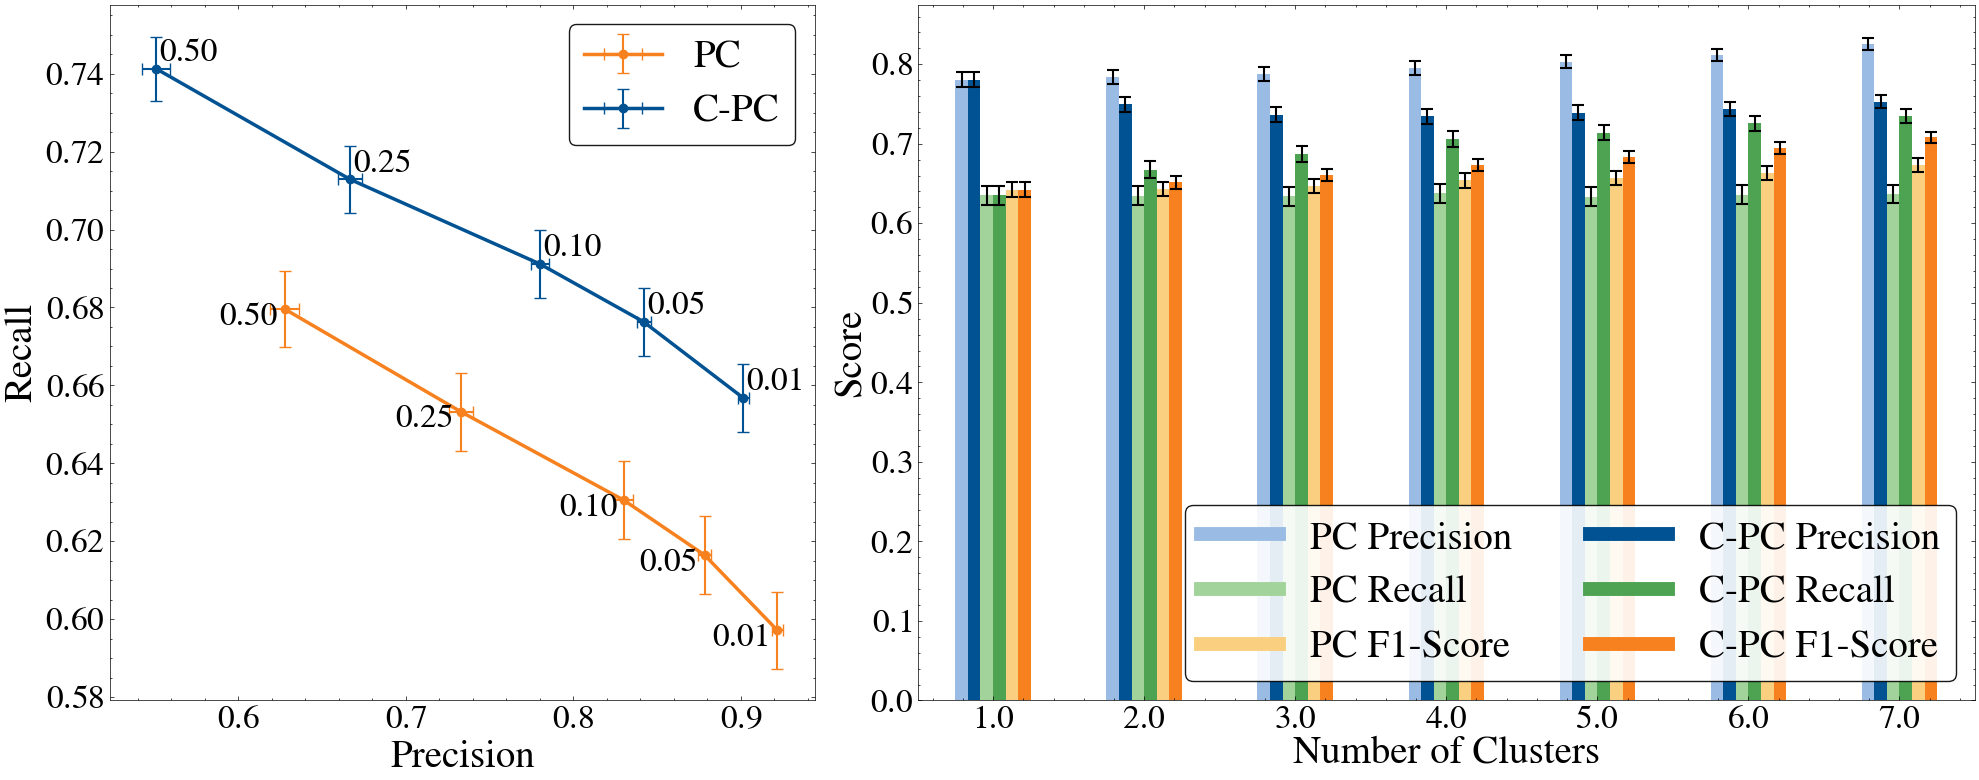

In [66]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from scipy import stats
plt.style.use(['science', 'no-latex'])

# Colors for the plots
colors_pr = ['#F7811E', '#005293']  # Dark orange and dark blue for Precision-Recall curve
colors_bar = ['#9ABCE4', '#005293', '#A2D39A', '#4DA351', '#FAD080', '#F7811E']  # TUM Colors

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Create the figure and specify gridspec for unequal subplot widths
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, width_ratios=[2, 3])  # 40% for ax1 and 60% for ax2

# First Plot: Precision-Recall Curve for different alpha values (mean +/- 95% CI)
ax1 = fig.add_subplot(gs[0])
grouped_stats = data_all.groupby('alpha')[prec_recall_metrics].agg(['mean', 'sem', 'count']).fillna(0)
grouped_mean = grouped_stats.xs('mean', axis=1, level=1)
grouped_se = grouped_stats.xs('sem', axis=1, level=1)
grouped_n = grouped_stats.xs('count', axis=1, level=1)
grouped_ci = t_ci_halfwidth(grouped_se, grouped_n, confidence=ci_level)

# Plot for PC with x/y CI error bars
ax1.errorbar(
    grouped_mean['base_adj_precision'],
    grouped_mean['base_adj_recall'],
    xerr=grouped_ci['base_adj_precision'],
    yerr=grouped_ci['base_adj_recall'],
    fmt='-o',
    color=colors_pr[0],
    label='PC',
    linewidth=2.5,
    capsize=4,
    elinewidth=1.5
)
for alpha, x, y in zip(grouped_mean.index, grouped_mean['base_adj_precision'], grouped_mean['base_adj_recall']):
    offset = 0.004
    ax1.text(x - offset, y - offset, f'{alpha:.2f}', fontsize=24, ha='right')

# Plot for C-PC with x/y CI error bars
ax1.errorbar(
    grouped_mean['cluster_adj_precision'],
    grouped_mean['cluster_adj_recall'],
    xerr=grouped_ci['cluster_adj_precision'],
    yerr=grouped_ci['cluster_adj_recall'],
    fmt='-o',
    color=colors_pr[1],
    label='C-PC',
    linewidth=2.5,
    capsize=4,
    elinewidth=1.5
)
for alpha, x, y in zip(grouped_mean.index, grouped_mean['cluster_adj_precision'], grouped_mean['cluster_adj_recall']):
    offset = 0.002
    ax1.text(x + offset, y + offset, f'{alpha:.2f}', fontsize=24, ha='left')

# Set labels and style the legend for ax1
ax1.set_xlabel('Precision', fontsize=28)
ax1.set_ylabel('Recall', fontsize=28)
ax1.tick_params(axis='both', which='major', labelsize=24)

# Legend styled like the second plot but positioned at the top right
legend = ax1.legend(fontsize=28, loc='upper right', frameon=True, ncol=1)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(0.9)

# Second Plot: Bar plot for Precision, Recall, and F1-Score for Different Numbers of Clusters (mean +/- 95% CI)
ax2 = fig.add_subplot(gs[1])
pr_stats = data_all.groupby('n_clusters')[prec_recall_metrics].agg(['mean', 'sem', 'count']).fillna(0)
pr_mean = pr_stats.xs('mean', axis=1, level=1)
pr_se = pr_stats.xs('sem', axis=1, level=1)
pr_n = pr_stats.xs('count', axis=1, level=1)
pr_ci = t_ci_halfwidth(pr_se, pr_n, confidence=ci_level)
pr_mean.plot(
    kind='bar',
    ax=ax2,
    color=colors_bar,
    yerr=pr_ci,
    capsize=4,
    error_kw={'elinewidth': 1.5, 'capthick': 1.5}
 )

# Label enhancements for ax2
ax2.set_xlabel('Number of Clusters', fontsize=28, labelpad=1)
ax2.set_ylabel('Score', fontsize=28, labelpad=1)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)

# Define legend entries for ax2
label_names = ['PC Precision', 'PC Recall', 'PC F1-Score', 'C-PC Precision', 'C-PC Recall', 'C-PC F1-Score']
label_colors = {
    'PC Precision': '#9ABCE4', 'PC Recall': '#A2D39A', 'PC F1-Score': '#FAD080',
    'C-PC Precision': '#005293', 'C-PC Recall': '#4DA351', 'C-PC F1-Score': '#F7811E'
}

colored_handles = [plt.Line2D([0], [0], color=label_colors[label], lw=10) for label in label_names]
legend = ax2.legend(colored_handles, label_names, loc='lower right', fontsize=28, frameon=True, ncol=2)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_alpha(0.9)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('imgs/combined_prec_recall_clusters_diagram.pdf', bbox_inches='tight')
plt.show()

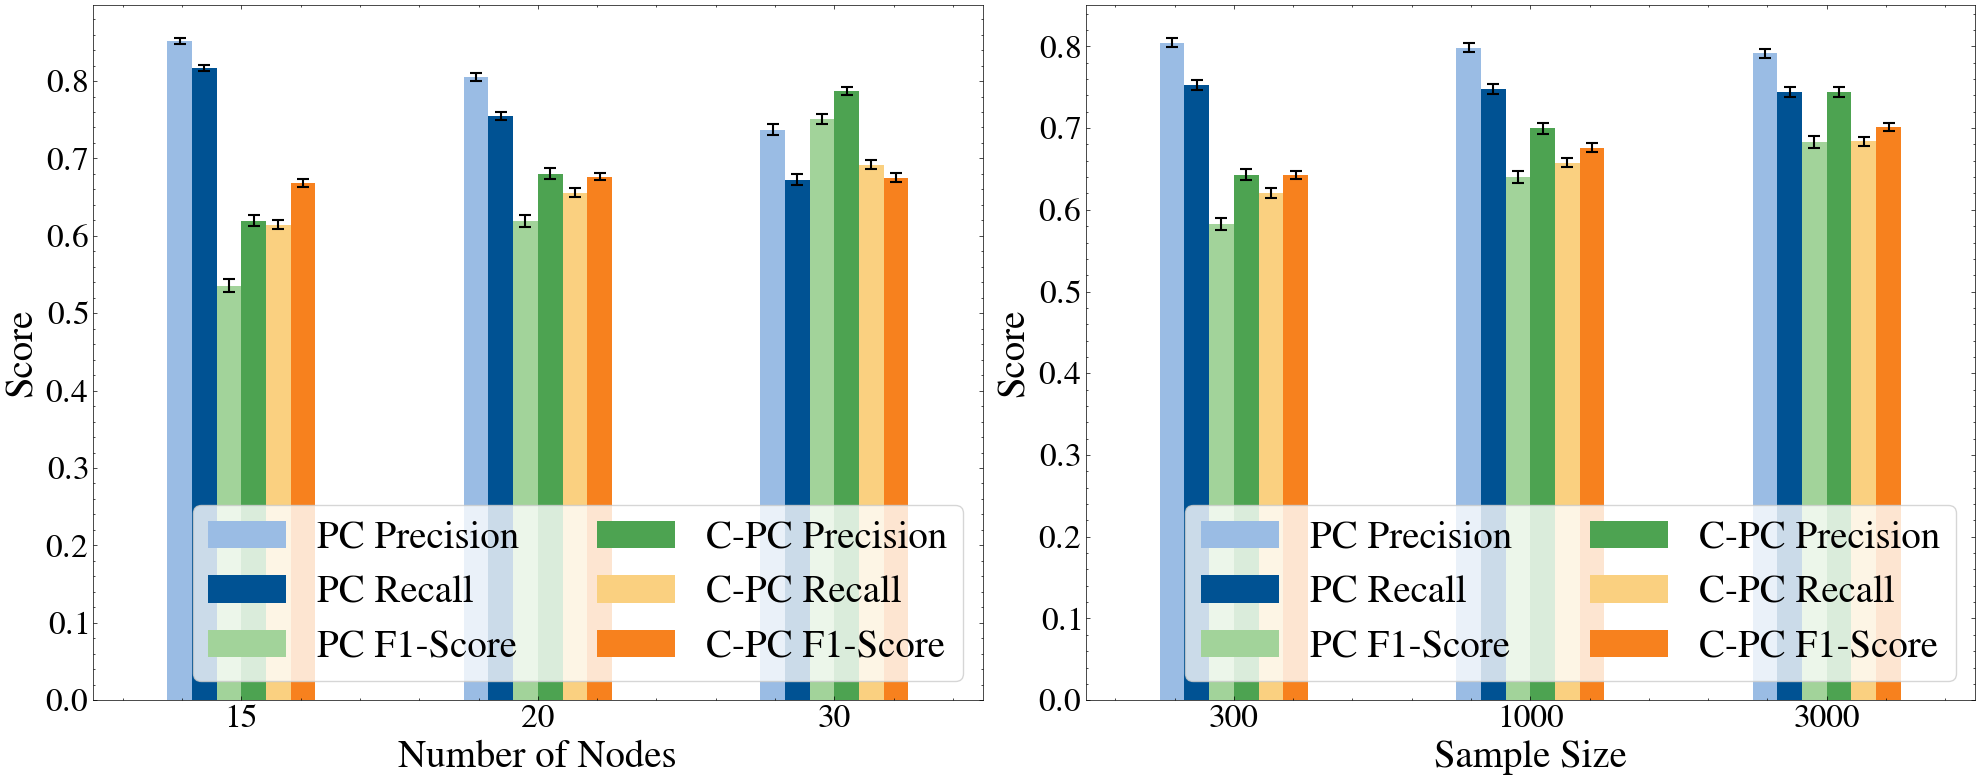

In [67]:
# Start here
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use(['science', 'no-latex'])

colors_bar = ['#9ABCE4', '#005293', '#A2D39A', '#4DA351', '#FAD080', '#F7811E']
label_names = ['PC Precision', 'PC Recall', 'PC F1-Score', 'C-PC Precision', 'C-PC Recall', 'C-PC F1-Score']
ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Left plot: grouped by number of nodes
nodes_stats = data_all.groupby('n_nodes')[prec_recall_metrics].agg(['mean', 'sem', 'count']).fillna(0)
nodes_mean = nodes_stats.xs('mean', axis=1, level=1)
nodes_se = nodes_stats.xs('sem', axis=1, level=1)
nodes_n = nodes_stats.xs('count', axis=1, level=1)
nodes_ci = t_ci_halfwidth(nodes_se, nodes_n, confidence=ci_level)

# Right plot: grouped by sample size
sample_stats = data_all.groupby('sample_size')[prec_recall_metrics].agg(['mean', 'sem', 'count']).fillna(0)
sample_mean = sample_stats.xs('mean', axis=1, level=1)
sample_se = sample_stats.xs('sem', axis=1, level=1)
sample_n = sample_stats.xs('count', axis=1, level=1)
sample_ci = t_ci_halfwidth(sample_se, sample_n, confidence=ci_level)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

nodes_mean.plot(
    kind='bar',
    ax=ax1,
    color=colors_bar,
    yerr=nodes_ci,
    capsize=4,
    error_kw={'elinewidth': 1.5, 'capthick': 1.5}
 )
ax1.set_xlabel('Number of Nodes', fontsize=28)
ax1.set_ylabel('Score', fontsize=28)
ax1.tick_params(axis='both', which='major', labelsize=24)
ax1.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax1.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax1.get_xticklabels()])
ax1.legend(label_names, loc='lower right', fontsize=28, frameon=True, ncol=2)

sample_mean.plot(
    kind='bar',
    ax=ax2,
    color=colors_bar,
    yerr=sample_ci,
    capsize=4,
    error_kw={'elinewidth': 1.5, 'capthick': 1.5}
 )
ax2.set_xlabel('Sample Size', fontsize=28)
ax2.set_ylabel('Score', fontsize=28)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax2.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax2.get_xticklabels()])
ax2.legend(label_names, loc='lower right', fontsize=28, frameon=True, ncol=2)

plt.tight_layout()
plt.savefig('imgs/combined_prec_recall_grouped_nodes_and_sample_size.pdf', bbox_inches='tight')
plt.show()

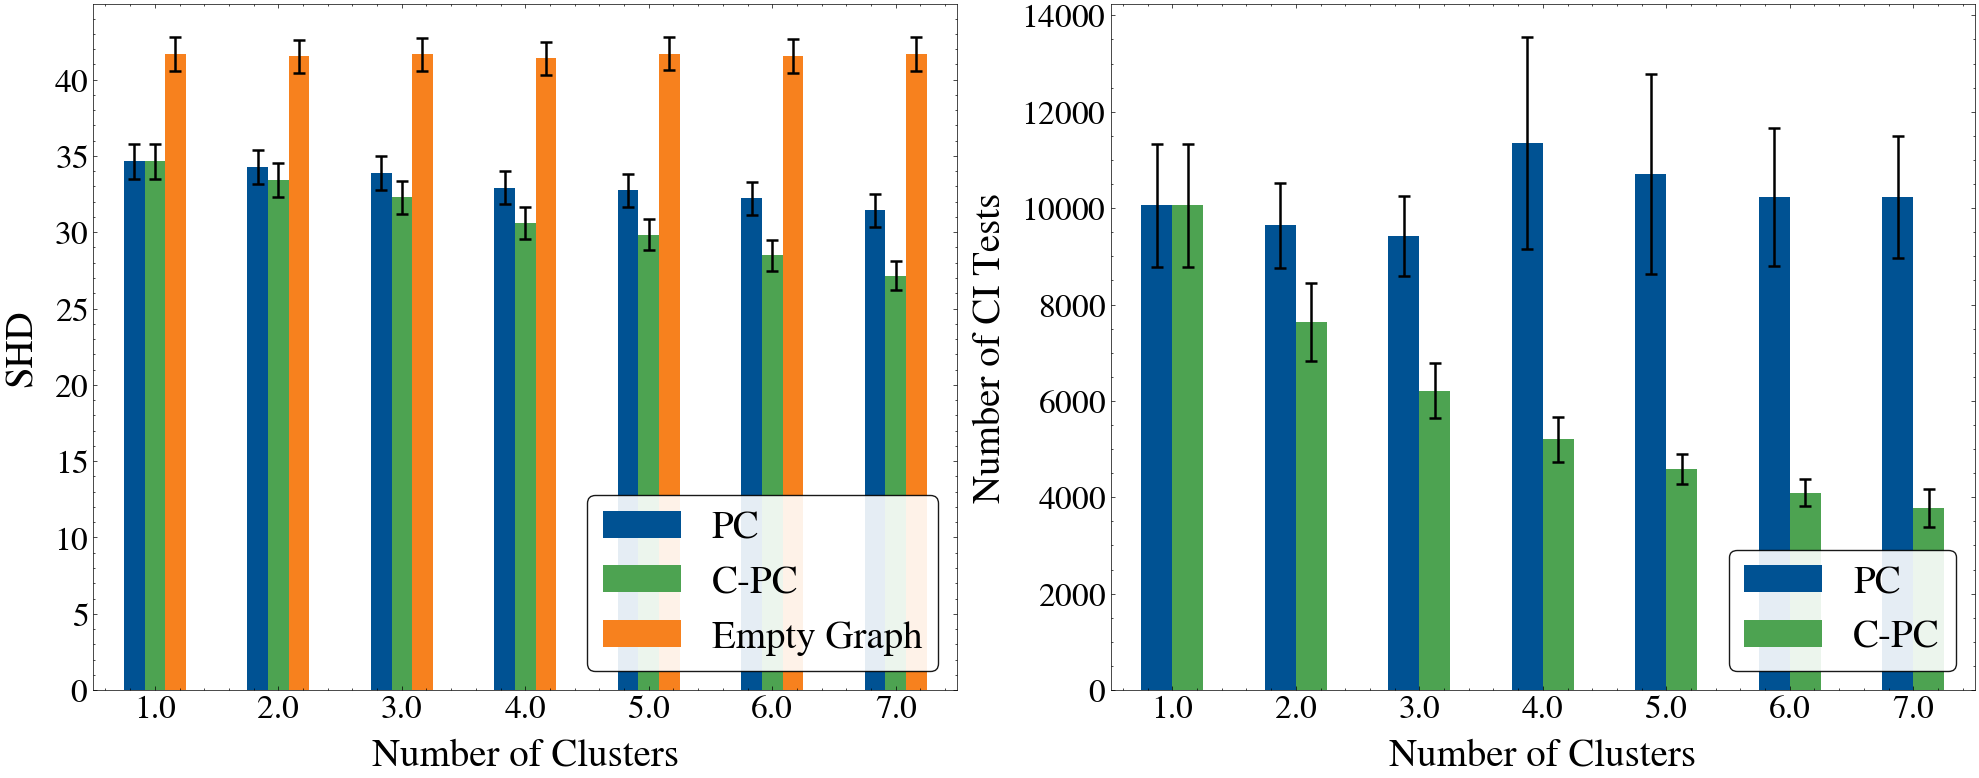

In [68]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
from scipy import stats

# Use the 'science' style from scienceplots
plt.style.use(['science', 'no-latex'])  # 'no-latex' avoids LaTeX processing for quicker rendering

# Define colors for each plot
colors_shd = ['#005293', '#4DA351', '#F7811E']
colors_ci_tests = colors_shd

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Aggregate mean and 95% t-based CI half-width
shd_stats = data_all.groupby('n_clusters')[dist_metrics].agg(['mean', 'sem', 'count']).fillna(0)
shd_mean = shd_stats.xs('mean', axis=1, level=1)
shd_se = shd_stats.xs('sem', axis=1, level=1)
shd_n = shd_stats.xs('count', axis=1, level=1)
shd_ci = t_ci_halfwidth(shd_se, shd_n, confidence=ci_level)

tests_stats = data_all.groupby('n_clusters')[indep_test_metrics].agg(['mean', 'sem', 'count']).fillna(0)
tests_mean = tests_stats.xs('mean', axis=1, level=1)
tests_se = tests_stats.xs('sem', axis=1, level=1)
tests_n = tests_stats.xs('count', axis=1, level=1)
tests_ci = t_ci_halfwidth(tests_se, tests_n, confidence=ci_level)

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))  # Side-by-side subplots

# First plot - SHD for different numbers of clusters (mean +/- 95% CI)
shd_mean.plot(
    kind='bar',
    ax=ax1,
    color=colors_shd,
    yerr=shd_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax1.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax1.set_ylabel('SHD', fontsize=28, labelpad=10)
ax1.tick_params(axis='both', which='major', labelsize=24)
ax1.tick_params(axis='x', which='major', labelsize=24, rotation=0)
label_names_shd = ['PC', 'C-PC', 'Empty Graph']
legend1 = ax1.legend(label_names_shd, loc='lower right', fontsize=28, frameon=True)
legend1.get_frame().set_facecolor('white')
legend1.get_frame().set_edgecolor('black')
legend1.get_frame().set_alpha(0.9)

# Second plot - Number of CI tests needed for different numbers of clusters (mean +/- 95% CI)
tests_mean.plot(
    kind='bar',
    ax=ax2,
    color=colors_ci_tests,
    yerr=tests_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax2.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax2.set_ylabel('Number of CI Tests', fontsize=28, labelpad=10)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)
label_names_ci = ['PC', 'C-PC']
legend2 = ax2.legend(label_names_ci, loc='lower right', fontsize=28, frameon=True)
legend2.get_frame().set_facecolor('white')
legend2.get_frame().set_edgecolor('black')
legend2.get_frame().set_alpha(0.9)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('imgs/combined_shd_ci_tests_clusters_diagram.pdf', bbox_inches='tight')
plt.show()

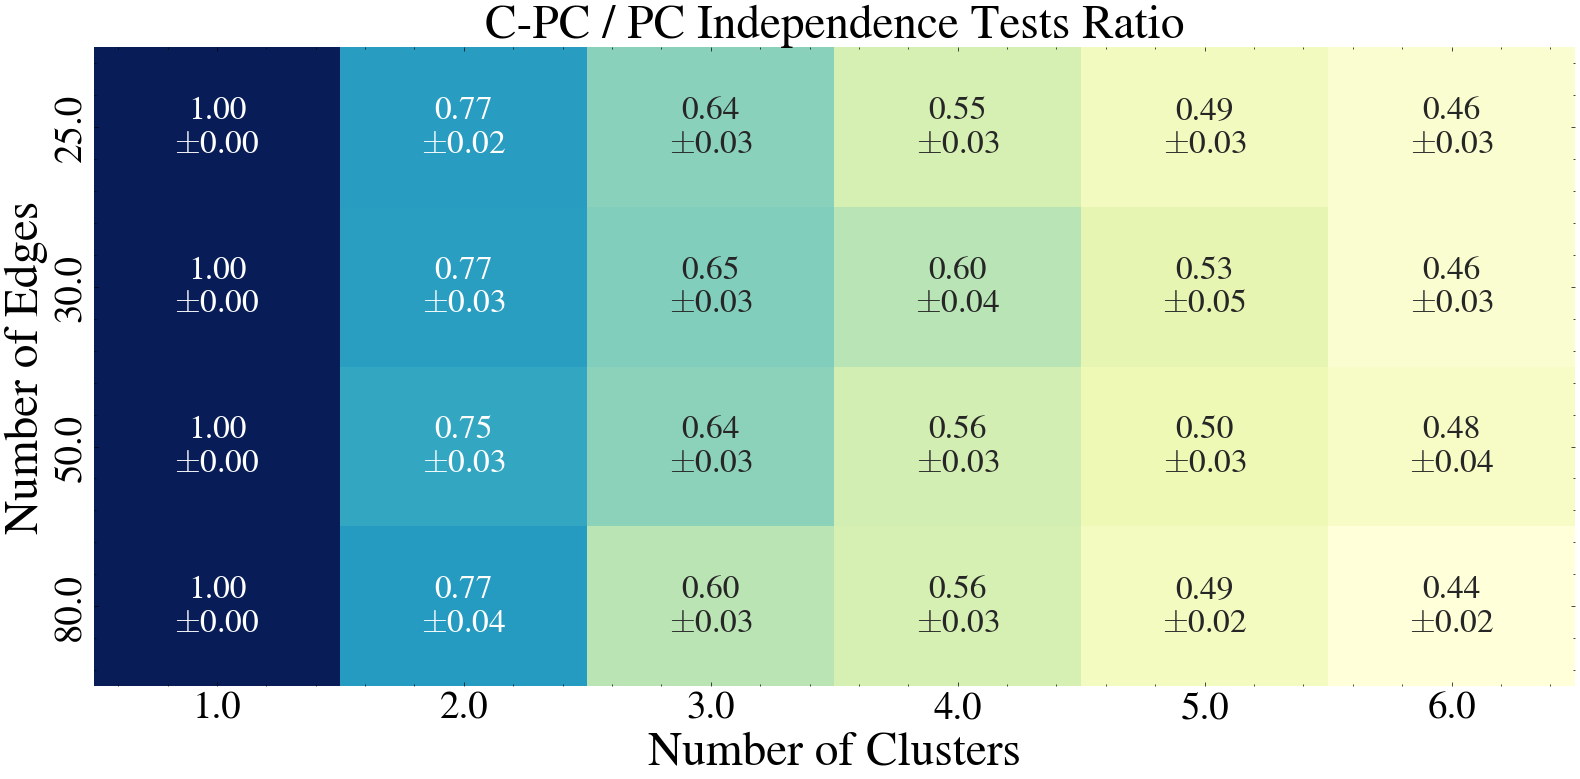

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Compute per-run ratio first, then aggregate mean/SE/count for the ratio
ratio_data = data.copy()
ratio_data['ratio_cluster_over_base'] = (
    ratio_data['Cluster indep tests'] / ratio_data['Base indep tests'].replace(0, np.nan)
)
ratio_data = ratio_data.replace([np.inf, -np.inf], np.nan)

ratio_stats = ratio_data.groupby(['n_edges', 'n_clusters'])['ratio_cluster_over_base'].agg(['mean', 'sem', 'count'])
ratio_mean = ratio_stats['mean'].unstack('n_clusters').fillna(0)
ratio_se = ratio_stats['sem'].unstack('n_clusters')
ratio_n = ratio_stats['count'].unstack('n_clusters')
ratio_ci = t_ci_halfwidth(ratio_se, ratio_n, confidence=ci_level).fillna(0)

# Create annotation strings as mean +/- 95% CI
ratio_annot = ratio_mean.copy().astype(object)
for row in ratio_mean.index:
    for col in ratio_mean.columns:
        ratio_annot.loc[row, col] = f"{ratio_mean.loc[row, col]:.2f}\n$\\pm${ratio_ci.loc[row, col]:.2f}"

plt.figure(figsize=(16, 8))
labelsize = 28
fontsize = 34
annot_fontsize = 24
sns.heatmap(
    ratio_mean,
    annot=ratio_annot,
    fmt='',
    cmap='YlGnBu',
    cbar=False,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': annot_fontsize}
 )
plt.title('C-PC / PC Independence Tests Ratio', fontsize=fontsize)
plt.xlabel('Number of Clusters', fontsize=fontsize)
plt.ylabel('Number of Edges', fontsize=fontsize)
plt.tick_params(axis='x', labelsize=labelsize)
plt.tick_params(axis='y', labelsize=labelsize)

# Adjust layout
plt.tight_layout()
plt.savefig('imgs/indep_tests_ratio_over_n_edges_heatmap.pdf', bbox_inches='tight')
plt.show()


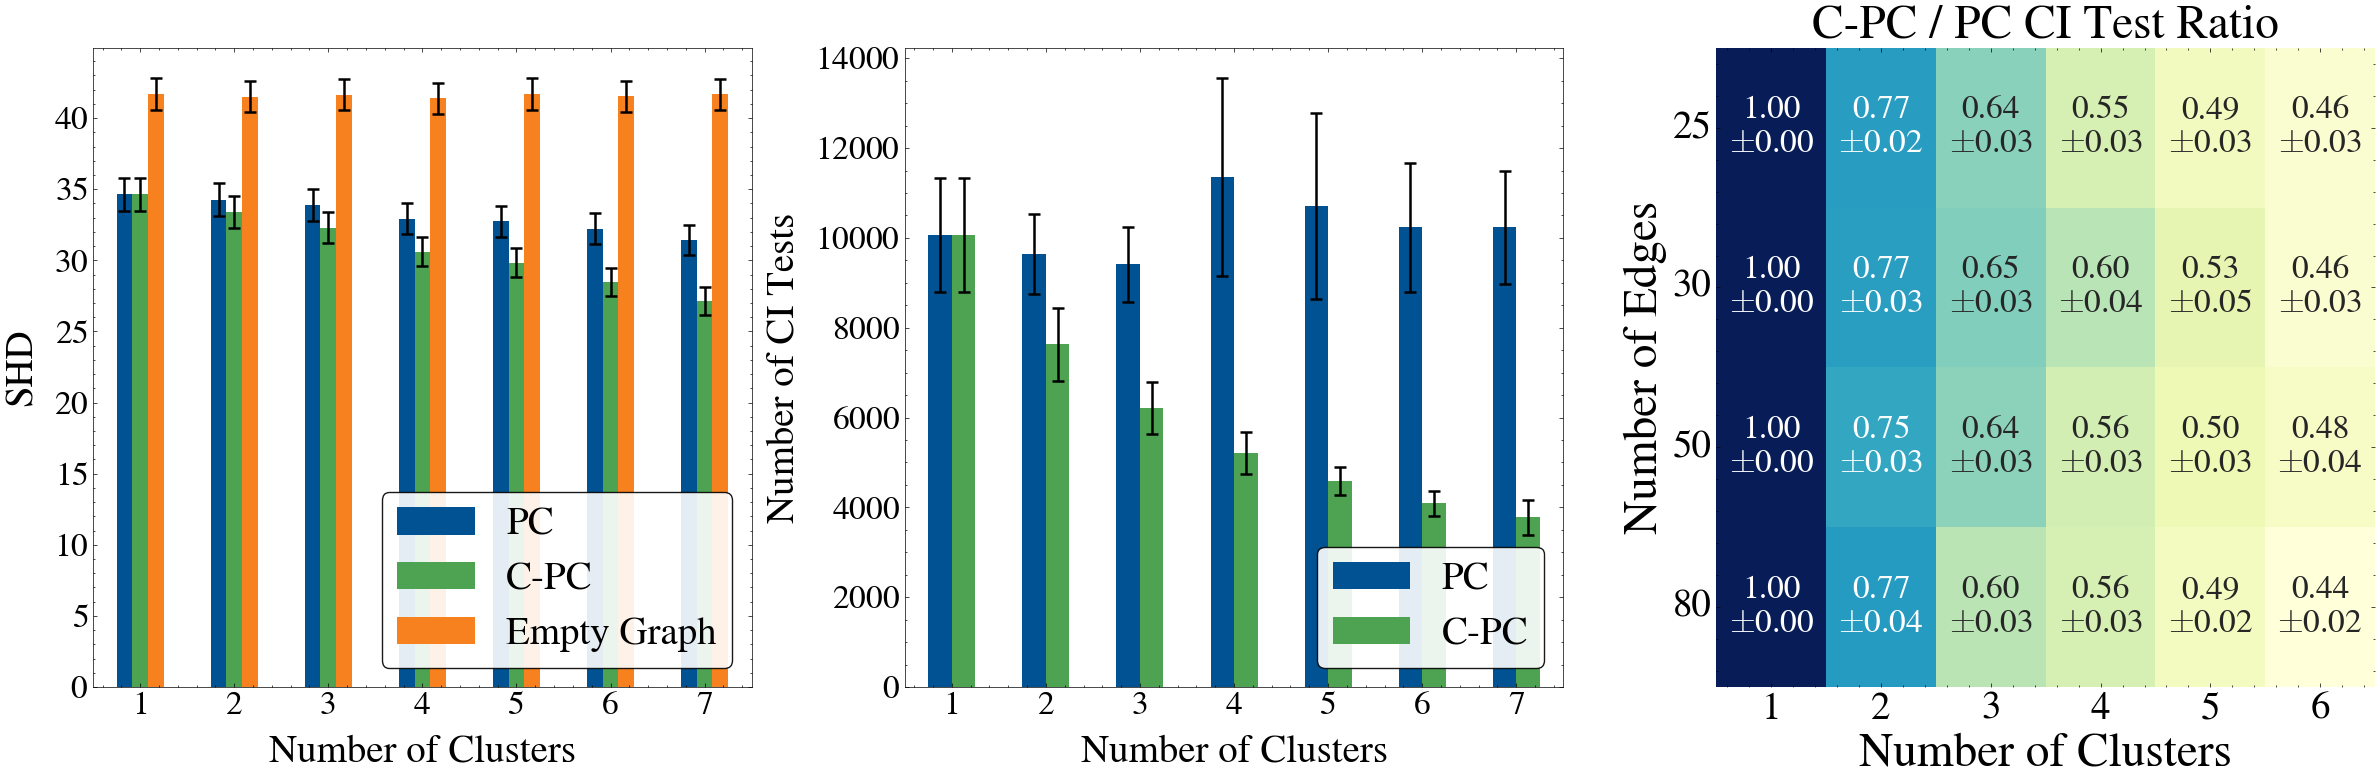

In [70]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
from scipy import stats
# import scienceplots # Removed due to unavailability

# Define colors for each plot
colors_shd = ['#005293', '#4DA351', '#F7811E']
colors_ci_tests = colors_shd

ci_level = 0.95

def t_ci_halfwidth(se_df, n_df, confidence=0.95):
    t_crit = n_df.apply(
        lambda col: col.map(
            lambda n: stats.t.ppf((1 + confidence) / 2, n - 1) if n > 1 else float('nan')
        )
    )
    return (se_df * t_crit).fillna(0)

# Aggregate mean/SE/count for bar plots
shd_stats = data_all.groupby('n_clusters')[dist_metrics].agg(['mean', 'sem', 'count']).fillna(0)
shd_mean = shd_stats.xs('mean', axis=1, level=1)
shd_se = shd_stats.xs('sem', axis=1, level=1)
shd_n = shd_stats.xs('count', axis=1, level=1)
shd_ci = t_ci_halfwidth(shd_se, shd_n, confidence=ci_level)

tests_stats = data_all.groupby('n_clusters')[indep_test_metrics].agg(['mean', 'sem', 'count']).fillna(0)
tests_mean = tests_stats.xs('mean', axis=1, level=1)
tests_se = tests_stats.xs('sem', axis=1, level=1)
tests_n = tests_stats.xs('count', axis=1, level=1)
tests_ci = t_ci_halfwidth(tests_se, tests_n, confidence=ci_level)

# Heatmap data: compute ratio per run first, then CI from ratio SE
ratio_data = data.copy()
ratio_data['ratio_cluster_over_base'] = (
    ratio_data['Cluster indep tests'] / ratio_data['Base indep tests'].replace(0, np.nan)
)
ratio_data = ratio_data.replace([np.inf, -np.inf], np.nan)

ratio_stats = ratio_data.groupby(['n_edges', 'n_clusters'])['ratio_cluster_over_base'].agg(['mean', 'sem', 'count'])
ratio_mean = ratio_stats['mean'].unstack('n_clusters').fillna(0)
ratio_se = ratio_stats['sem'].unstack('n_clusters')
ratio_n = ratio_stats['count'].unstack('n_clusters')
ratio_ci = t_ci_halfwidth(ratio_se, ratio_n, confidence=ci_level).fillna(0)

ratio_annot = ratio_mean.copy().astype(object)
for row in ratio_mean.index:
    for col in ratio_mean.columns:
        ratio_annot.loc[row, col] = f"{ratio_mean.loc[row, col]:.2f}\n$\\pm${ratio_ci.loc[row, col]:.2f}"

# Create the figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))  # Side-by-side subplots

# First plot - SHD for different numbers of clusters (mean +/- 95% CI)
shd_mean.plot(
    kind='bar',
    ax=ax1,
    color=colors_shd,
    yerr=shd_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax1.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax1.set_ylabel('SHD', fontsize=28, labelpad=10)
ax1.tick_params(axis='both', which='major', labelsize=24)
ax1.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax1.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax1.get_xticklabels()])
label_names_shd = ['PC', 'C-PC', 'Empty Graph']
legend1 = ax1.legend(label_names_shd, loc='lower right', fontsize=28, frameon=True)
legend1.get_frame().set_facecolor('white')
legend1.get_frame().set_edgecolor('black')
legend1.get_frame().set_alpha(0.9)

# Second plot - Number of CI tests needed for different numbers of clusters (mean +/- 95% CI)
tests_mean.plot(
    kind='bar',
    ax=ax2,
    color=colors_ci_tests,
    yerr=tests_ci,
    capsize=4,
    error_kw={'elinewidth': 1.8, 'capthick': 1.8}
 )
ax2.set_xlabel('Number of Clusters', fontsize=28, labelpad=10)
ax2.set_ylabel('Number of CI Tests', fontsize=28, labelpad=10)
ax2.tick_params(axis='both', which='major', labelsize=24)
ax2.tick_params(axis='x', which='major', labelsize=24, rotation=0)
ax2.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax2.get_xticklabels()])
label_names_ci = ['PC', 'C-PC']
legend2 = ax2.legend(label_names_ci, loc='lower right', fontsize=28, frameon=True)
legend2.get_frame().set_facecolor('white')
legend2.get_frame().set_edgecolor('black')
legend2.get_frame().set_alpha(0.9)

# Third Plot - Ratio heatmap with mean +/- 95% CI annotations
labelsize = 28
fontsize = 34
annot_fontsize = 24
sns.heatmap(
    ratio_mean,
    annot=ratio_annot,
    fmt='',
    cmap='YlGnBu',
    cbar=False,
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': annot_fontsize},
    ax=ax3
)
ax3.set_title('C-PC / PC CI Test Ratio', fontsize=fontsize)
ax3.set_xlabel('Number of Clusters', fontsize=fontsize)
ax3.set_ylabel('Number of Edges', fontsize=fontsize)
ax3.tick_params(axis='x', labelsize=labelsize)
ax3.tick_params(axis='y', labelsize=labelsize)
ax3.set_xticklabels([f"{int(float(label.get_text()))}" for label in ax3.get_xticklabels()], rotation=0)
ax3.set_yticklabels([f"{int(float(label.get_text()))}" for label in ax3.get_yticklabels()], rotation=0)

# Adjust layout and save the figure
plt.tight_layout()
plt.savefig('imgs/combined_shd_ci_tests_clusters_diagram_and_ci_test_ratios_over_edges.pdf', bbox_inches='tight')
plt.show()

# Tables

In [71]:
from clustercausal.utils.Utils import metrics_in_readable_table
import pandas as pd

simul1data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_pc_simulation_1new.pkl')
# simul1data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul2data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_pc_simulation_2new.pkl')
# simul2data.rename(columns={'C-PC indep tests': 'Cluster indep tests'}, inplace=True)
simul3data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_vsfcitiers_simulation_3new.pkl')
simul4data = pd.read_pickle('clustercausal\\experiments\\_results_dataframes_for_simulations\\cluster_vsfcitiers_on_tiers_simulation_4new.pkl')

def _col_mean(df, candidates):
    for col in candidates:
        if col in df.columns:
            return pd.to_numeric(df[col], errors='coerce').mean()
    return float('nan')

def _fmt_pct(x):
    return f"{100 * x:.1f}%" if pd.notna(x) else "N/A"

def _fmt_float(x):
    return f"{x:.1f}" if pd.notna(x) else "N/A"

def _fmt_int(x):
    return f"{int(round(x))}" if pd.notna(x) else "N/A"

def build_pretty_pc_cluster_table(df):
    metric_specs = [
        ('Adj. precision', ['base_adj_precision'], ['cluster_adj_precision'], 'pct'),
        ('Arrow precision', ['base_arrow_precision'], ['cluster_arrow_precision'], 'pct'),
        ('Adj. recall', ['base_adj_recall'], ['cluster_adj_recall'], 'pct'),
        ('Arrow recall', ['base_arrow_recall'], ['cluster_arrow_recall'], 'pct'),
        ('Adj. F1-score', ['base_adj_f1_score'], ['cluster_adj_f1_score'], 'pct'),
        ('Arrow F1-score', ['base_arrow_f1_score'], ['cluster_arrow_f1_score'], 'pct'),
        ('SHD', ['base_shd', 'base_base_shd'], ['cluster_shd', 'cluster_cluster_shd'], 'float'),
        ('Avg. CI tests', ['base_indep_tests', 'Base indep tests'], ['cluster_indep_tests', 'Cluster indep tests', 'C-PC indep tests'], 'int'),
    ]

    rows = []
    for metric_name, base_cols, cluster_cols, fmt in metric_specs:
        base_val = _col_mean(df, base_cols)
        cluster_val = _col_mean(df, cluster_cols)

        if fmt == 'pct':
            base_show, cluster_show = _fmt_pct(base_val), _fmt_pct(cluster_val)
        elif fmt == 'int':
            base_show, cluster_show = _fmt_int(base_val), _fmt_int(cluster_val)
        else:
            base_show, cluster_show = _fmt_float(base_val), _fmt_float(cluster_val)

        rows.append([metric_name, base_show, cluster_show])

    return pd.DataFrame(rows, columns=['Metric', 'PC', 'Cluster-PC'])

def build_pretty_fci_cluster_fcitiers_table(df):
    metric_specs = [
        ('Adj. precision', ['base_adj_precision'], ['cluster_adj_precision'], ['fcitiers_adj_precision'], 'pct'),
        ('Arrow precision', ['base_arrow_precision'], ['cluster_arrow_precision'], ['fcitiers_arrow_precision'], 'pct'),
        ('Adj. recall', ['base_adj_recall'], ['cluster_adj_recall'], ['fcitiers_adj_recall'], 'pct'),
        ('Arrow recall', ['base_arrow_recall'], ['cluster_arrow_recall'], ['fcitiers_arrow_recall'], 'pct'),
        ('Adj. F1-score', ['base_adj_f1_score'], ['cluster_adj_f1_score'], ['fcitiers_adj_f1_score'], 'pct'),
        ('Arrow F1-score', ['base_arrow_f1_score'], ['cluster_arrow_f1_score'], ['fcitiers_arrow_f1_score'], 'pct'),
        ('SHD', ['base_shd', 'base_base_shd'], ['cluster_shd', 'cluster_cluster_shd'], ['fcitiers_shd', 'fcitiers_fcitiers_shd'], 'float'),
        ('Avg. CI tests', ['base_indep_tests', 'Base indep tests'], ['cluster_indep_tests', 'Cluster indep tests'], ['fcitiers_indep_tests', 'FCITiers indep tests'], 'int'),
    ]

    rows = []
    for metric_name, base_cols, cluster_cols, fcitiers_cols, fmt in metric_specs:
        base_val = _col_mean(df, base_cols)
        cluster_val = _col_mean(df, cluster_cols)
        fcitiers_val = _col_mean(df, fcitiers_cols)

        if fmt == 'pct':
            base_show = _fmt_pct(base_val)
            cluster_show = _fmt_pct(cluster_val)
            fcitiers_show = _fmt_pct(fcitiers_val)
        elif fmt == 'int':
            base_show = _fmt_int(base_val)
            cluster_show = _fmt_int(cluster_val)
            fcitiers_show = _fmt_int(fcitiers_val)
        else:
            base_show = _fmt_float(base_val)
            cluster_show = _fmt_float(cluster_val)
            fcitiers_show = _fmt_float(fcitiers_val)

        rows.append([metric_name, base_show, cluster_show, fcitiers_show])

    return pd.DataFrame(rows, columns=['Metric', 'FCI', 'C-FCI', 'FCITiers'])

In [72]:
rename_dict = {
    'Base indep tests': 'base_indep_tests',
    'Cluster indep tests': 'cluster_indep_tests',
    'base_base_shd': 'base_shd',
    'cluster_cluster_shd': 'cluster_shd',
}

simul1data_pretty = simul1data.rename(columns=rename_dict).copy()
pretty_table_simul1 = build_pretty_pc_cluster_table(simul1data_pretty)
display(pretty_table_simul1)

,Metric,PC,Cluster-PC
0,Adj. precision,79.8%,74.8%
1,Arrow precision,54.6%,66.4%
2,Adj. recall,63.5%,69.6%
3,Arrow recall,33.9%,58.7%
4,Adj. F1-score,65.4%,67.3%
5,Arrow F1-score,38.5%,58.1%
6,SHD,33.2,30.9
7,Avg. CI tests,10235,5938


In [79]:
simul2data_pretty = simul2data.rename(columns=rename_dict).copy()
pretty_table_simul2 = build_pretty_pc_cluster_table(simul2data_pretty)

# Simulation 2 breakdown tables: split into four compact tables
simul2_breakdown = simul2data_pretty.copy()

distribution_map_pretty = {
    'gauss': 'Gaussian',
    'exp': 'Exponential',
    'gumbel': 'Gumbel',
    'logistic': 'Logistic',
    'mim': 'MIM',
    'mlp': 'MLP',
    'gp': 'GP',
}
dag_method_map_pretty = {
    'erdos_renyi': 'Erdős–Rényi',
    'hierarchical': 'Hierarchical',
    'scale_free': 'Scale free',
}

def _pretty_group_value(value, group_col):
    if pd.isna(value):
        return 'N/A'
    if group_col == 'distribution_type' and value in distribution_map_pretty:
        return distribution_map_pretty[value]
    if group_col == 'dag_method' and value in dag_method_map_pretty:
        return dag_method_map_pretty[value]
    return value

def build_sim2_grouped_pretty_table(df, group_col, group_label, metric_specs):
    if group_col not in df.columns:
        return pd.DataFrame(columns=[group_label] + [m[0] for m in metric_specs])

    rows = []
    for group_value, group_df in df.groupby(group_col, dropna=False):
        row = {group_label: _pretty_group_value(group_value, group_col)}
        for metric_name, candidate_cols, fmt in metric_specs:
            value = _col_mean(group_df, candidate_cols)
            if fmt == 'pct':
                row[metric_name] = _fmt_pct(value)
            else:
                row[metric_name] = _fmt_float(value)
        rows.append(row)

    result = pd.DataFrame(rows)
    return result.sort_values(by=group_label, key=lambda s: s.astype(str)).reset_index(drop=True)

adj_metric_specs = [
    ('Adj. precision (PC)', ['base_adj_precision'], 'pct'),
    ('Adj. precision (C-PC)', ['cluster_adj_precision'], 'pct'),
    ('Adj. recall (PC)', ['base_adj_recall'], 'pct'),
    ('Adj. recall (C-PC)', ['cluster_adj_recall'], 'pct'),
    ('Adj. F1-score (PC)', ['base_adj_f1_score'], 'pct'),
    ('Adj. F1-score (C-PC)', ['cluster_adj_f1_score'], 'pct'),
    ('SHD (PC)', ['base_shd', 'base_base_shd'], 'float'),
    ('SHD (C-PC)', ['cluster_shd', 'cluster_cluster_shd'], 'float'),
]

arrow_metric_specs = [
    ('Arrow precision (PC)', ['base_arrow_precision'], 'pct'),
    ('Arrow precision (C-PC)', ['cluster_arrow_precision'], 'pct'),
    ('Arrow recall (PC)', ['base_arrow_recall'], 'pct'),
    ('Arrow recall (C-PC)', ['cluster_arrow_recall'], 'pct'),
    ('Arrow F1-score (PC)', ['base_arrow_f1_score'], 'pct'),
    ('Arrow F1-score (C-PC)', ['cluster_arrow_f1_score'], 'pct'),
]

pretty_table_simul2_distribution_adj = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='distribution_type',
    group_label='Distribution',
    metric_specs=adj_metric_specs
)
display(pretty_table_simul2_distribution_adj)

pretty_table_simul2_distribution_arrow = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='distribution_type',
    group_label='Distribution',
    metric_specs=arrow_metric_specs
)
display(pretty_table_simul2_distribution_arrow)

pretty_table_simul2_dag_method_adj = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='dag_method',
    group_label='DAG method',
    metric_specs=adj_metric_specs
)
display(pretty_table_simul2_dag_method_adj)

pretty_table_simul2_dag_method_arrow = build_sim2_grouped_pretty_table(
    simul2_breakdown,
    group_col='dag_method',
    group_label='DAG method',
    metric_specs=arrow_metric_specs
)
display(pretty_table_simul2_dag_method_arrow)

,Distribution,Adj. precision (PC),Adj. precision (C-PC),Adj. recall (PC),Adj. recall (C-PC),Adj. F1-score (PC),Adj. F1-score (C-PC),SHD (PC),SHD (C-PC)
0,Exponential,88.8%,86.7%,44.5%,51.2%,55.2%,60.8%,60.5,54.5
1,Gaussian,88.6%,86.6%,44.5%,51.6%,55.2%,61.2%,60.7,54.5
2,Gumbel,89.6%,87.6%,45.1%,51.9%,55.9%,61.6%,60.9,54.9
3,Logistic,92.3%,90.8%,57.6%,60.7%,68.3%,70.4%,50.9,44.1
4,MIM,88.4%,86.6%,62.5%,65.9%,69.8%,71.6%,52.2,45.7


,Distribution,Arrow precision (PC),Arrow precision (C-PC),Arrow recall (PC),Arrow recall (C-PC),Arrow F1-score (PC),Arrow F1-score (C-PC)
0,Exponential,65.6%,78.1%,25.5%,43.0%,34.3%,52.4%
1,Gaussian,66.6%,77.6%,26.1%,43.0%,35.2%,52.4%
2,Gumbel,66.3%,78.3%,26.0%,43.1%,35.1%,52.6%
3,Logistic,62.3%,77.4%,33.5%,49.0%,41.9%,58.0%
4,MIM,61.0%,74.4%,37.6%,53.6%,44.5%,59.7%


,DAG method,Adj. precision (PC),Adj. precision (C-PC),Adj. recall (PC),Adj. recall (C-PC),Adj. F1-score (PC),Adj. F1-score (C-PC),SHD (PC),SHD (C-PC)
0,Erdős–Rényi,89.1%,86.4%,63.1%,67.7%,71.5%,74.1%,29.7,24.9
1,Hierarchical,92.0%,91.8%,26.2%,32.9%,39.4%,47.2%,116.1,106.0
2,Scale free,87.5%,84.8%,63.3%,68.2%,71.7%,74.2%,25.4,21.4


,DAG method,Arrow precision (PC),Arrow precision (C-PC),Arrow recall (PC),Arrow recall (C-PC),Arrow F1-score (PC),Arrow F1-score (C-PC)
0,Erdős–Rényi,58.4%,73.7%,34.1%,54.5%,41.6%,61.1%
1,Hierarchical,76.2%,85.3%,20.7%,30.1%,31.2%,43.2%
2,Scale free,58.4%,72.5%,34.3%,54.4%,41.8%,60.8%


In [74]:
rename_dict = {
    'Base indep tests' : 'base_indep_tests',
    'Cluster indep tests' : 'cluster_indep_tests', 
    'FCITiers indep tests' : 'fcitiers_indep_tests',
    'base_base_shd' : 'base_shd',
    'cluster_cluster_shd': 'cluster_shd',
    'fcitiers_fcitiers_shd': 'fcitiers_shd'
}
simul3data_pretty = simul3data.rename(columns=rename_dict).copy()
pretty_table_simul3 = build_pretty_fci_cluster_fcitiers_table(simul3data_pretty)
display(pretty_table_simul3)

,Metric,FCI,C-FCI,FCITiers
0,Adj. precision,29.2%,28.2%,26.6%
1,Arrow precision,20.4%,24.1%,25.2%
2,Adj. recall,17.6%,19.7%,18.4%
3,Arrow recall,10.1%,16.1%,13.7%
4,Adj. F1-score,21.2%,22.5%,21.0%
5,Arrow F1-score,12.8%,18.6%,17.0%
6,SHD,38.4,40.5,39.8
7,Avg. CI tests,1585,918,1746


In [75]:
simul4data_pretty = simul4data.rename(columns=rename_dict).copy()
pretty_table_simul4 = build_pretty_fci_cluster_fcitiers_table(simul4data_pretty)
display(pretty_table_simul4)

,Metric,FCI,C-FCI,FCITiers
0,Adj. precision,92.1%,89.9%,89.7%
1,Arrow precision,70.5%,81.3%,80.5%
2,Adj. recall,71.0%,71.7%,71.7%
3,Arrow recall,46.4%,50.1%,50.9%
4,Adj. F1-score,79.1%,78.6%,78.4%
5,Arrow F1-score,54.5%,60.8%,61.1%
6,SHD,19.4,16.2,16.8
7,Avg. CI tests,1686,959,1775


In [76]:
# Hyperparameter overview table for all simulations
import pandas as pd
import numpy as np

simulations = {
    'Simulation 1': simul1data,
    'Simulation 2': simul2data,
    'Simulation 3': simul3data,
    'Simulation 4': simul4data,
}

dag_method_map = {
    'erdos_renyi': 'Erdős–Rényi',
    'scale_free': 'scale-free',
    'hierarchical': 'hierarchical',
}
distribution_map = {
    'gauss': 'Gaussian',
    'exp': 'Exponential',
    'gumbel': 'Gumbel',
    'logistic': 'Logistic',
    'mim': 'MIM',
    'mlp': 'MLP',
    'gp': 'GP',
}

def _normalize_value(v):
    if isinstance(v, str):
        if v in dag_method_map:
            return dag_method_map[v]
        if v in distribution_map:
            return distribution_map[v]
        return v
    if isinstance(v, (np.integer, int)):
        return int(v)
    if isinstance(v, (np.floating, float)):
        if np.isfinite(v) and float(v).is_integer():
            return int(v)
        return float(v)
    return v

def _format_unique(df, col):
    if col not in df.columns:
        return 'N/A'
    values = [v for v in df[col].dropna().unique().tolist()]
    values = [_normalize_value(v) for v in values]
    values = sorted(values, key=lambda x: str(x))
    if len(values) == 0:
        return 'N/A'
    if len(values) == 1:
        return values[0]
    return values

def _infer_algorithms(df):
    has_fcitiers = any(c.startswith('fcitiers_') for c in df.columns)
    if has_fcitiers:
        return 'FCI, FCITiers, C-FCI'
    return 'PC, C-PC'

def _runs_per_configuration(df):
    config_cols = [
        c
        for c in [
            'dag_method',
            'distribution_type',
            'alpha',
            'indep_test',
            'n_nodes',
            'n_edges',
            'n_clusters',
            'sample_size',
            'weight_range',
            'cluster_method',
            'scm_method',
        ]
        if c in df.columns
    ]
    if len(config_cols) == 0:
        return 'N/A'
    counts = df.groupby(config_cols, dropna=False).size()
    uniq_counts = sorted(counts.unique().tolist())
    if len(uniq_counts) == 1:
        return int(uniq_counts[0])
    return [int(v) for v in uniq_counts]

summary_rows = [
    'Algorithms',
    'Total number of graphs',
    'Runs per configuration',
    'DAG generation method',
    'Distribution',
    'Alpha for CI test',
    'CI test',
    'Number of nodes',
    'Number of edges',
    'Number of clusters',
    'Sample size',
    'Weight range',
    'Cluster method',
]

summary = pd.DataFrame(index=summary_rows, columns=simulations.keys(), dtype=object)

for sim_name, df in simulations.items():
    summary.loc['Algorithms', sim_name] = _infer_algorithms(df)
    summary.loc['Total number of graphs', sim_name] = int(len(df))
    summary.loc['Runs per configuration', sim_name] = _runs_per_configuration(df)
    summary.loc['DAG generation method', sim_name] = _format_unique(df, 'dag_method')
    summary.loc['Distribution', sim_name] = _format_unique(df, 'distribution_type')
    summary.loc['Alpha for CI test', sim_name] = _format_unique(df, 'alpha')
    summary.loc['CI test', sim_name] = _format_unique(df, 'indep_test')
    summary.loc['Number of nodes', sim_name] = _format_unique(df, 'n_nodes')
    summary.loc['Number of edges', sim_name] = _format_unique(df, 'n_edges')
    summary.loc['Number of clusters', sim_name] = _format_unique(df, 'n_clusters')
    summary.loc['Sample size', sim_name] = _format_unique(df, 'sample_size')
    summary.loc['Weight range', sim_name] = _format_unique(df, 'weight_range')
    summary.loc['Cluster method', sim_name] = _format_unique(df, 'cluster_method')

display(summary)

,Simulation 1,Simulation 2,Simulation 3,Simulation 4
Algorithms,"PC, C-PC","PC, C-PC","FCI, FCITiers, C-FCI","FCI, FCITiers, C-FCI"
Total number of graphs,12600,3240,1620,1620
Runs per configuration,10,1,10,20
DAG generation method,Erdős–Rényi,"[Erdős–Rényi, hierarchical, scale-free]",Erdős–Rényi,Erdős–Rényi
Distribution,Gaussian,"[Exponential, Gaussian, Gumbel, Logistic, MIM]",Gaussian,Gaussian
Alpha for CI test,"[0.01, 0.05, 0.1, 0.25, 0.5]",0.05,0.05,0.05
CI test,fisherz,fisherz,fisherz,fisherz
Number of nodes,"[15, 20, 30]","[15, 20, 25]","[18, 24, 36]","[15, 20, 30]"
Number of edges,"[15, 30, 50, 80]","[25, 30, 50, 80]","[22, 29, 36]","[15, 20, 25]"
Number of clusters,"[1, 2, 3, 4, 5, 6, 7]","[1, 2, 3, 4, 5, 6]","[2, 3, 4, 5, 6, 7]","[3, 4, 5]"


In [80]:
# Quick export: save displayed tables as LaTeX files under imgs/tables
from pathlib import Path

export_dir = Path("imgs") / "tables"
export_dir.mkdir(parents=True, exist_ok=True)

table_specs = [
    ("sim1_pc_vs_clusterpc.tex", "pretty_table_simul1", False),
    ("sim2_distribution_adj.tex", "pretty_table_simul2_distribution_adj", False),
    ("sim2_distribution_arrow.tex", "pretty_table_simul2_distribution_arrow", False),
    ("sim2_dag_method_adj.tex", "pretty_table_simul2_dag_method_adj", False),
    ("sim2_dag_method_arrow.tex", "pretty_table_simul2_dag_method_arrow", False),
    ("sim3_fci_vs_clusterfci_vs_fcitiers.tex", "pretty_table_simul3", False),
    ("sim4_fci_vs_clusterfci_vs_fcitiers.tex", "pretty_table_simul4", False),
    ("simulations_hyperparameter_summary.tex", "summary", True),
]

saved_files = []
for filename, var_name, keep_index in table_specs:
    df = globals().get(var_name)
    if df is None:
        print(f"Skipped {filename}: variable '{var_name}' not found (run table cells first).")
        continue
    output_path = export_dir / filename
    latex_str = df.to_latex(index=keep_index, escape=False)
    output_path.write_text(latex_str, encoding="utf-8")
    saved_files.append(output_path)
    print(f"Saved {output_path}")

print(f"Done. Exported {len(saved_files)} table(s) to {export_dir.resolve()}")

Saved imgs\tables\sim1_pc_vs_clusterpc.tex
Saved imgs\tables\sim2_distribution_adj.tex
Saved imgs\tables\sim2_distribution_arrow.tex
Saved imgs\tables\sim2_dag_method_adj.tex
Saved imgs\tables\sim2_dag_method_arrow.tex
Saved imgs\tables\sim3_fci_vs_clusterfci_vs_fcitiers.tex
Saved imgs\tables\sim4_fci_vs_clusterfci_vs_fcitiers.tex
Saved imgs\tables\simulations_hyperparameter_summary.tex
Done. Exported 8 table(s) to C:\Users\ga87val\00_PhD\000 Paper Development\ClusterDAGs_causal_discovery\clustercausal\imgs\tables


In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
